In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


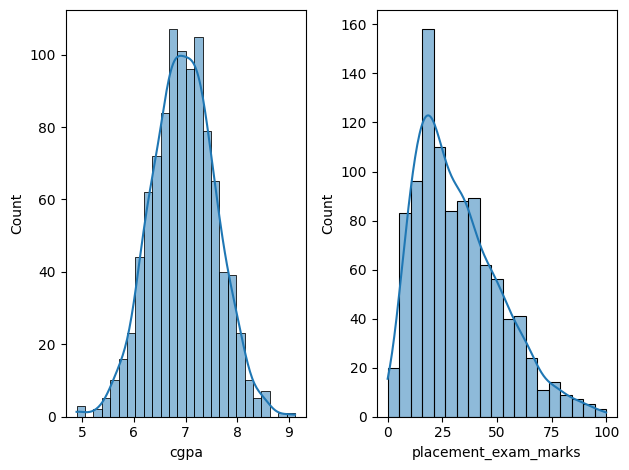

In [3]:
plt.subplot(1, 2, 1)
sns.histplot(df["cgpa"], kde=True)

plt.subplot(1, 2, 2)
sns.histplot(df["placement_exam_marks"], kde=True)

plt.tight_layout()
plt.show()

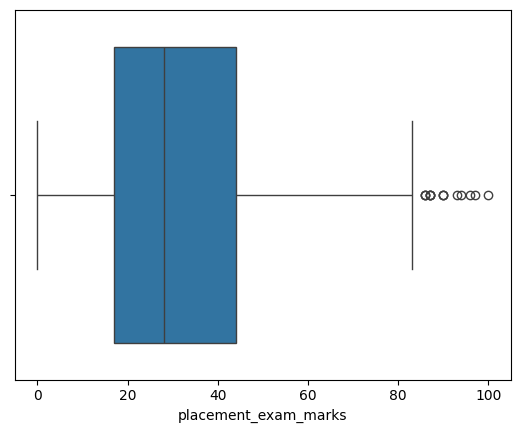

In [7]:
sns.boxplot(x=df["placement_exam_marks"])
plt.show()

In [8]:
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [11]:
percentile25 = df["placement_exam_marks"].quantile(0.25)
percentile75 = df["placement_exam_marks"].quantile(0.75)

In [12]:
percentile75

np.float64(44.0)

In [13]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [14]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [15]:
print("Upper limit:", upper_limit)
print("Lower limit:", lower_limit)

Upper limit: 84.5
Lower limit: -23.5


In [16]:
df[(df["placement_exam_marks"] > upper_limit) | (df["placement_exam_marks"] < lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [18]:
# Trimming 
new_df = df[(df["placement_exam_marks"] < upper_limit) & (df["placement_exam_marks"] > lower_limit)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


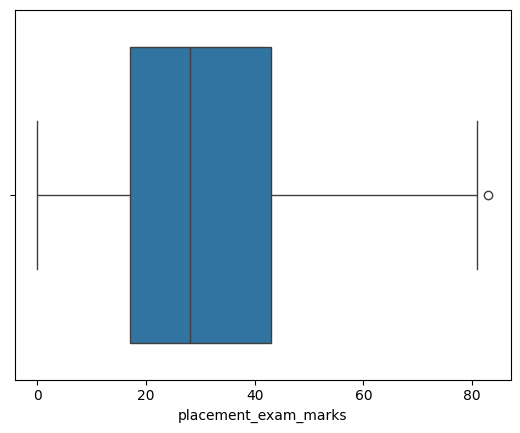

In [19]:
sns.boxplot(x=new_df["placement_exam_marks"])
plt.show()

In [20]:
# Capping 

df["placement_exam_marks"] = np.where(
    df["placement_exam_marks"] > upper_limit,
    upper_limit,
    np.where(
        df["placement_exam_marks"] < lower_limit,
        lower_limit,
        df["placement_exam_marks"]
    )
)

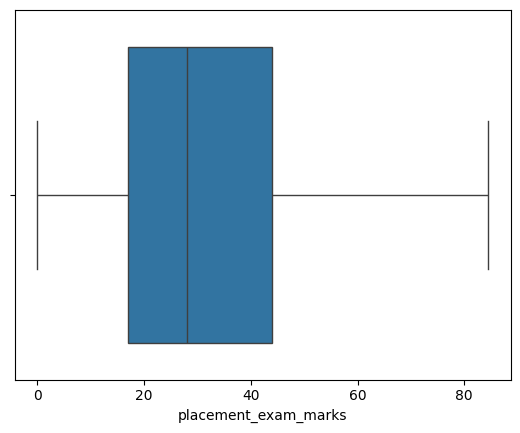

In [21]:
sns.boxplot(x=df["placement_exam_marks"])
plt.show()